<a href="https://colab.research.google.com/github/Aryanpratap9835/Codeforces/blob/main/RockFall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 3000  # slightly more data

data = {
    "tilt_change": np.random.normal(0.6, 0.4, n),
    "vibration_rms": np.random.normal(1.2, 0.5, n),
    "rainfall_mm": np.random.exponential(3.0, n),
    "crack_growth_mm": np.random.normal(0.25, 0.15, n),
    "blast_gap_hr": np.random.uniform(1, 72, n)
}

df = pd.DataFrame(data)

# ✅ Corrected risk logic
risk = (
    (df["tilt_change"] > 1.0).astype(int) +
    (df["vibration_rms"] > 1.5).astype(int) +
    (df["rainfall_mm"] > 4.5).astype(int) +
    (df["crack_growth_mm"] > 0.4).astype(int)
)

df["risk_level"] = pd.cut(
    risk,
    bins=[-1, 1, 2, 4],
    labels=["Low", "Medium", "High"]
)

print(df["risk_level"].value_counts())

df.to_csv("sensor_data.csv", index=False)


risk_level
Low       2480
Medium     443
High        77
Name: count, dtype: int64


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tilt_change      3000 non-null   float64
 1   vibration_rms    3000 non-null   float64
 2   rainfall_mm      3000 non-null   float64
 3   crack_growth_mm  3000 non-null   float64
 4   blast_gap_hr     3000 non-null   float64
 5   risk_level       3000 non-null   object 
dtypes: float64(5), object(1)
memory usage: 140.8+ KB

--- Statistics ---
       tilt_change  vibration_rms  rainfall_mm  crack_growth_mm  blast_gap_hr
count  3000.000000    3000.000000  3000.000000      3000.000000   3000.000000
mean      0.612800       1.180878     2.878895         0.248678     36.952030
std       0.394723       0.504413     2.817592         0.145140     20.330231
min      -0.696507      -0.388352     0.000158        -0.338360      1.017924
25%       0.348984       0.843719     0.8

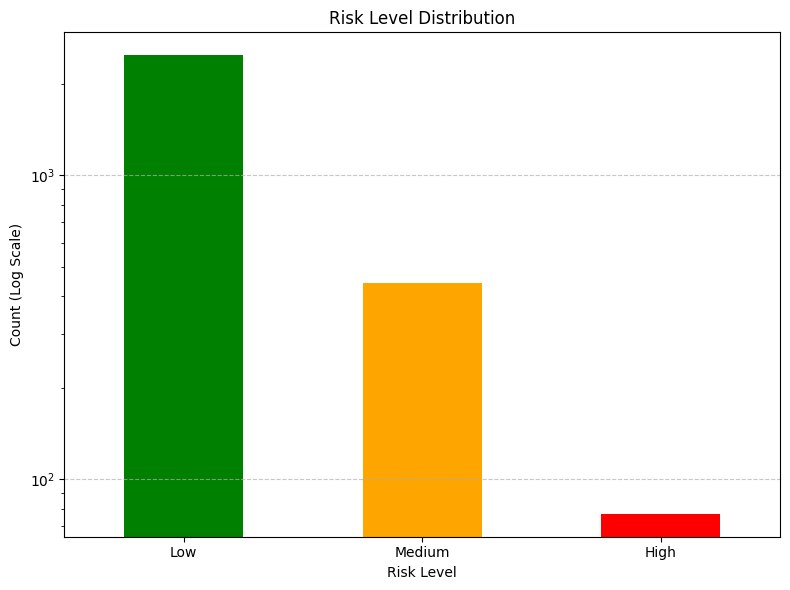

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns=["risk_level"])
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 11   0   4]
 [  0 496   0]
 [  0   5  84]]
              precision    recall  f1-score   support

        High       1.00      0.73      0.85        15
         Low       0.99      1.00      0.99       496
      Medium       0.95      0.94      0.95        89

    accuracy                           0.98       600
   macro avg       0.98      0.89      0.93       600
weighted avg       0.99      0.98      0.98       600



In [13]:
import numpy as np

# Get prediction probabilities
proba = model.predict_proba(X_test)

# Convert to DataFrame
proba_df = pd.DataFrame(proba, columns=model.classes_)

# Alert rule
alerts = (
    (proba_df["High"] > 0.6) |
    ((proba_df["High"] > 0.4) & (proba_df["Medium"] > 0.4))
)

alert_count = alerts.sum()

print("Total alerts triggered:", alert_count)


Total alerts triggered: 11
